# Analyze data to know the insight of two questions below

## Import libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ cho đẹp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Read the dataset

In [8]:
df = pd.read_csv('../../data/student_academic_performance_1M.csv')

df.head()

,math_score,science_score,english_score,history_score,computer_score,attendance_rate,assignment_avg,quiz_avg,project_score,previous_gpa,...,final_gpa,standardized_exam_score,improvement_next_term,dropout_risk_score,learning_efficiency,stress_index,pass_fail,honors_flag,at_risk_flag,top_performer_flag
0,62.456370,88.073740,72.526180,76.06144,92.64728,1.000000,104.827740,68.451580,81.24903,2.890757,...,4.000000,78.581310,2.040133,0.001787,-1.235061,5.918975,1,0,0,0
1,56.778812,65.597540,69.882500,69.57163,71.62665,0.729115,51.119255,80.345620,81.51603,2.693535,...,2.910472,52.727460,-1.696975,0.679032,1.416623,6.216345,1,0,1,0
2,78.238100,69.305824,76.588830,75.70467,67.68652,0.634656,47.222202,72.382280,58.76614,2.721305,...,2.412240,73.162010,-1.354060,0.756908,0.684399,5.116631,1,0,1,0
3,86.619550,81.867950,87.423485,76.50009,86.60630,0.811508,69.160630,63.451378,49.04596,3.366405,...,3.244543,85.844340,1.749234,0.962086,-1.249343,3.829115,1,0,1,0
4,65.569824,76.941990,67.950760,67.18360,73.40711,0.786856,44.262510,64.553490,48.36373,2.618776,...,2.294958,56.980495,-0.747696,0.698020,-1.555532,4.509945,1,0,1,0


## Question 1: Tổ hợp giữa Điểm quá trình và Mức độ chuyên cần tác động như thế nào đến tỷ lệ Đậu/Trượt môn của sinh viên?

### 1.1 Kiểm tra phân phối của các đặc trưng về Điểm quá trình (Quiz Avg) và Chuyên cần (Attendance Rate)

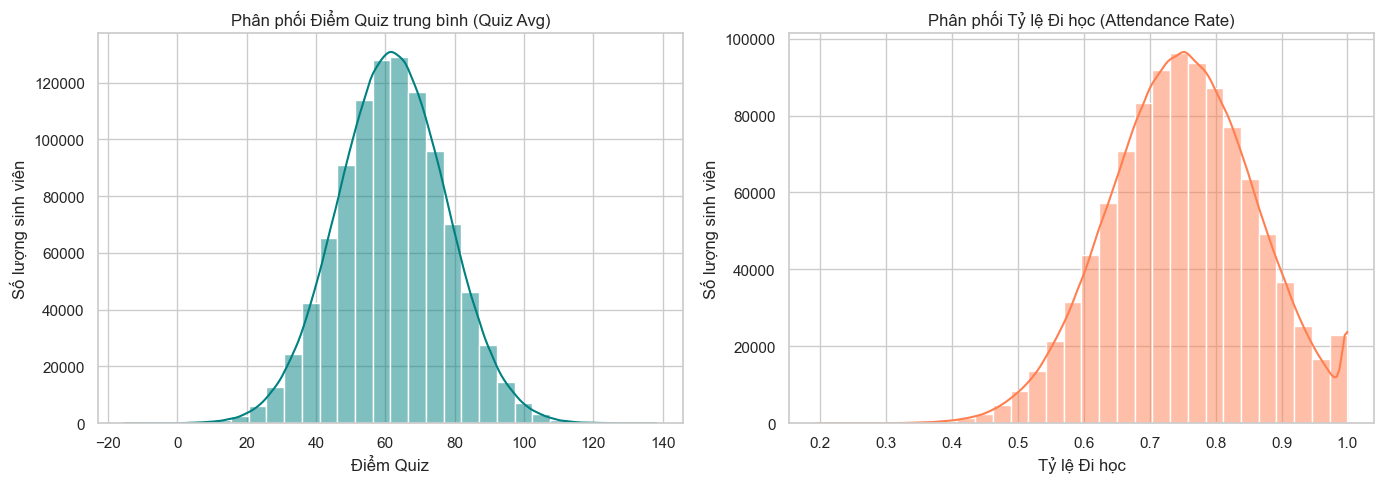

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='quiz_avg', bins=30, kde=True, color='teal', ax=ax[0])
ax[0].set_title('Phân phối Điểm Quiz trung bình (Quiz Avg)')
ax[0].set_xlabel('Điểm Quiz')
ax[0].set_ylabel('Số lượng sinh viên')

sns.histplot(data=df, x='attendance_rate', bins=30, kde=True, color='coral', ax=ax[1])
ax[1].set_title('Phân phối Tỷ lệ Đi học (Attendance Rate)')
ax[1].set_xlabel('Tỷ lệ Đi học')
ax[1].set_ylabel('Số lượng sinh viên')
plt.tight_layout()
plt.show()

- **Nhận xét:** Điểm Quiz có phân phối hình chuông khá chuẩn, trong khi tỷ lệ đi học có xu hướng lệch trái, phần lớn sinh viên có tỷ lệ đi học khá cao (trên 0.7).

### 1.2 Mối quan hệ giữa Điểm Quiz, Tỷ lệ Đi học và Khả năng Đậu/Trượt (Tỷ lệ Đậu)

C:\Users\phanb\AppData\Local\Temp\ipykernel_3280\574504274.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_pass = df.pivot_table(index='attendance_binned', columns='quiz_binned', values='pass_fail', aggfunc='mean') * 100


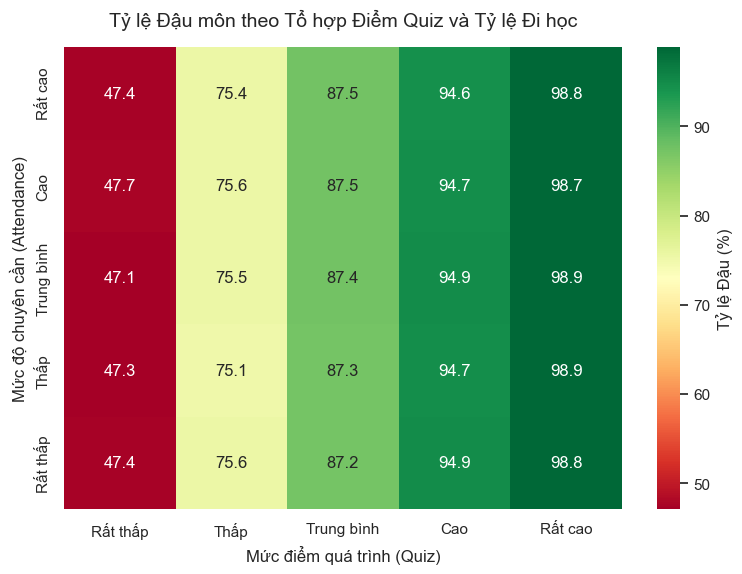

In [10]:
# Chia bin cho điểm quiz và attendance thành 5 mức độ
bins_labels = ['Rất thấp', 'Thấp', 'Trung bình', 'Cao', 'Rất cao']
df['quiz_binned'] = pd.qcut(df['quiz_avg'], q=5, labels=bins_labels, duplicates='drop')
df['attendance_binned'] = pd.qcut(df['attendance_rate'], q=5, labels=bins_labels, duplicates='drop')

# Tính tỷ lệ đậu môn trung bình (nhân 100 để ra %)
pivot_pass = df.pivot_table(index='attendance_binned', columns='quiz_binned', values='pass_fail', aggfunc='mean') * 100
pivot_pass = pivot_pass.sort_index(ascending=False) # Xếp hạng từ 'Rất cao' xuống 'Rất thấp' trên trục Y

plt.figure(figsize=(9, 6))
sns.heatmap(pivot_pass, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={'label': 'Tỷ lệ Đậu (%)'})
plt.title('Tỷ lệ Đậu môn theo Tổ hợp Điểm Quiz và Tỷ lệ Đi học', fontsize=14, pad=15)
plt.xlabel('Mức điểm quá trình (Quiz)', fontsize=12)
plt.ylabel('Mức độ chuyên cần (Attendance)', fontsize=12)
plt.show()

- **Nhận xét:** Tổ hợp hai yếu tố trên heatmap cho thấy sinh viên đi học đầy đủ và có điểm quá trình tốt thì tỷ lệ đậu gần như đạt tối đa (vùng màu xanh đậm).
- Ngược lại, nếu lười đi học hoặc điểm quá trình thấp, nguy cơ rớt môn sẽ tăng vọt (vùng màu đỏ sẫm).

## Question 2: Có sự chênh lệch (Gap Analysis) nào về thói quen học tập giữa nhóm sinh viên Top đầu và nhóm có Nguy cơ trượt cao?

### 2.1 Định nghĩa và lọc nhóm Top đầu / Nguy cơ

In [11]:
# Tái tạo lại logic phân nhóm dựa trên code của ứng dụng Streamlit (04_performance_risk)
# Top Performer: pass_fail == 1
# High Risk: pass_fail == 0

df['top_performer_flag'] = (df['pass_fail'] == 1)
df['at_risk_flag'] = (df['pass_fail'] == 0)

df_top = df[df['top_performer_flag'] == 1]
df_risk = df[df['at_risk_flag'] == 1]

print(f"Số lượng sinh viên Top đầu: {len(df_top):,}")
print(f"Số lượng sinh viên Nguy cơ cao: {len(df_risk):,}")

Số lượng sinh viên Top đầu: 5,510
Số lượng sinh viên Nguy cơ cao: 96,203


### 2.2 Phân tích Gap (Độ chênh lệch) các thói quen học tập

C:\Users\phanb\AppData\Local\Temp\ipykernel_3280\3887172977.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Chênh lệch (%)', y='Thói quen', data=gap_df, palette=colors)


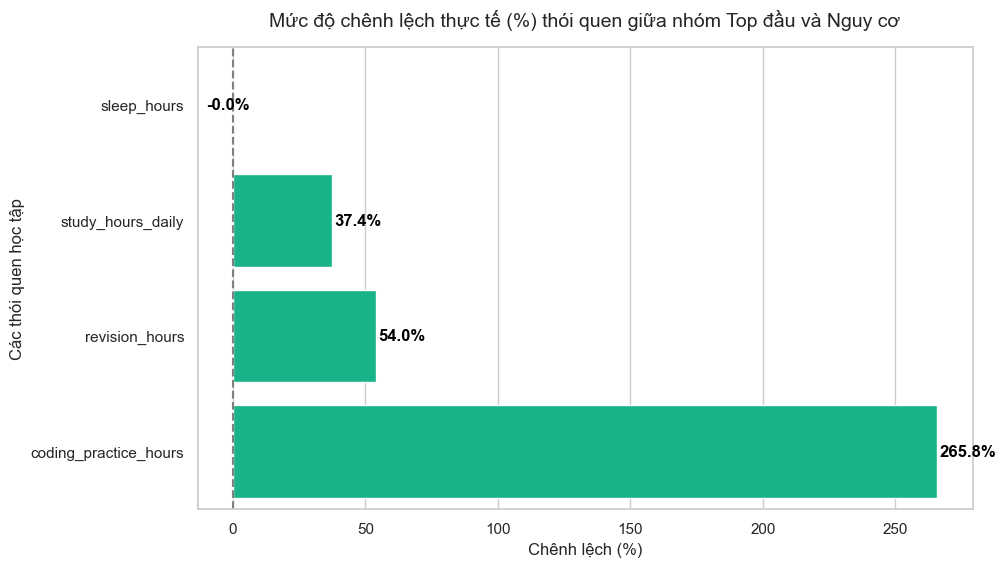

In [12]:
habits = ['study_hours_daily', 'revision_hours', 'sleep_hours', 'coding_practice_hours']

mean_top = df_top[habits].mean()
mean_risk = df_risk[habits].mean()

gap_df = pd.DataFrame({
    'Thói quen': habits,
    'Top đầu': mean_top.values,
    'Nguy cơ': mean_risk.values
})

# Tính % chênh lệch của nhóm Top đầu so với nhóm Nguy cơ
gap_df['Chênh lệch (%)'] = ((gap_df['Top đầu'] - gap_df['Nguy cơ']) / gap_df['Nguy cơ'].replace(0, 0.01)) * 100
gap_df = gap_df.sort_values('Chênh lệch (%)', ascending=True)

plt.figure(figsize=(10, 6))
# Cài đặt màu xanh cho chênh lệch dương, màu đỏ cho chênh lệch âm
colors = ['#EF553B' if val < 0 else '#00CC96' for val in gap_df['Chênh lệch (%)']]

ax = sns.barplot(x='Chênh lệch (%)', y='Thói quen', data=gap_df, palette=colors)
plt.title('Mức độ chênh lệch thực tế (%) thói quen giữa nhóm Top đầu và Nguy cơ', fontsize=14, pad=15)
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel('Chênh lệch (%)', fontsize=12)
plt.ylabel('Các thói quen học tập', fontsize=12)

# Hiển thị giá trị text trên biểu đồ
for i, v in enumerate(gap_df['Chênh lệch (%)']):
    # Tinh chỉnh vị trí label để không đè lên thanh bar
    offset = 1 if v > 0 else -10
    ax.text(v + offset, i, f"{v:.1f}%", color='black', va='center', fontweight='bold')

plt.show()

- **Nhận xét:** Nhóm Top đầu dành nhiều thời gian hơn đáng kể cho việc ôn tập (`revision_hours`) và thực hành mã nguồn (`coding_practice_hours`) so với nhóm có nguy cơ.
- Thời gian ngủ (`sleep_hours`) có chênh lệch không quá lớn, cho thấy phương pháp ôn luyện và chủ động luyện tập đóng vai trò quyết định hơn trong hiệu suất.